# Lab 10 — Uncertainty and Error Propagation 

**Learning Objectives**
- Understand uncertainty propagation for functions of **two variables**: $f=f(x,y)$.
- Interpret **partial derivatives** as sensitivities (without calculus formulas).
- Use **finite differences** to estimate $\dfrac{\partial f}{\partial x}$ and $\dfrac{\partial f}{\partial y}$ numerically.
- Apply the propagation formula to **synthetic data** and compare to a Monte Carlo simulation.

---
## Background - Error Propagation: Single Variable Functions

When a physical quantity $ y $ depends on a *single measured variable* $ x $, the uncertainty in $ y $ arises from the uncertainty in $ x $.

If $ y = f(x) $, then for small uncertainties, the **differential** $ dy $ provides a first-order estimate of the change in $ y $:

$$
dy = \frac{df}{dx} \, dx.
$$

Taking absolute values, the **uncertainty in $ y $** is approximately:

$$
\sigma_y = \left| \frac{df}{dx} \right| \, \sigma_x,
$$

where:
- $ \sigma_x $ = uncertainty in the measurement of $ x $,
- $ \sigma_y $ = propagated uncertainty in $ y $.

This linear approximation assumes the uncertainty is small enough that higher-order terms can be neglected — a **first-order approximation**.

---

### Example: Volume of a Sphere

Suppose we measure the radius $ r $ of a small sphere as:

$$
r = 5.00 \pm 0.05 \text{ cm.}
$$

The volume is:

$$
V = \frac{4}{3}\pi r^3.
$$

Using the differential form:

$$
dV = 4\pi r^2 \, dr,
$$

we can estimate the uncertainty in $ V $:

$$
\sigma_V = \left| \frac{dV}{dr} \right| \sigma_r = 4\pi r^2 \sigma_r.
$$

Substituting the measured values:

$$
\sigma_V = 4\pi (5.00)^2 (0.05) = 15.7 \text{ cm}^3.
$$

Thus:

$$
V = 523.6 \pm 15.7 \text{ cm}^3.
$$

---

### Discussion

- The *relative uncertainty* can be expressed as:

  $$
  \frac{\sigma_V}{V} = 3 \frac{\sigma_r}{r},
  $$
  
  which shows that the uncertainty in the volume is **three times larger (in percentage)** than that of the radius, since $ V \propto r^3 $.

This example highlights how small measurement errors can amplify when the measured quantity is raised to a power — an important consideration in all physical measurements.

---

## 1) Motivation

Every experiment has measurement uncertainty. When a calculated result $f$ depends on two (or more) measured quantities $x$ and $y$, their uncertainties combine to produce an uncertainty in $f$.

If $f=f(x,y)$, then for small, independent uncertainties, we can use the first order approximation:

$$
\sigma_f^2 \;\approx\;
\left(\frac{\partial f}{\partial x}\right)^2\sigma_x^2
+
\left(\frac{\partial f}{\partial y}\right)^2\sigma_y^2,
\qquad
\sigma_f=\sqrt{\sigma_f^2}.
$$

This is called the **error propagation formula**, and it tells us how much uncertainty each variable contributes to the final result.

>*Note*:
The formula below is a first-order (linear) approximation, valid when the function behaves nearly linearly around the measured means.
It is derived by keeping only the first-order terms in a Taylor expansion of $f(x,y)$.
Later in this lab, we will compare this linear propagation to a Monte Carlo simulation that includes the nonlinear effects automatically.

---

## 2) The Idea of Partial Derivatives

When $f$ depends on two variables $x$ and $y$, a **partial derivative** measures how sensitive $f$ is to one variable at a time, while holding the other fixed.

We write:

$$
\frac{\partial f}{\partial x} \quad \text{and} \quad \frac{\partial f}{\partial y}.
$$

- $\dfrac{\partial f}{\partial x}$: “How much $f$ changes if $x$ changes a little, while $y$ stays fixed.”  
- $\dfrac{\partial f}{\partial y}$: “How much $f$ changes if $y$ changes a little, while $x$ stays fixed.”

---

### Example

If $f(x,y)=x\,y$, then:
- $\dfrac{\partial f}{\partial x}=y$  
- $\dfrac{\partial f}{\partial y}=x$

Each variable affects $f$ independently, and the larger the partial derivative, the more that variable’s uncertainty matters.

---

### Connecting to Uncertainty

Small deviations $\Delta x$ and $\Delta y$ change $f$ approximately by:

$$
\Delta f \;\approx\; \frac{\partial f}{\partial x}\,\Delta x + \frac{\partial f}{\partial y}\,\Delta y.
$$

Replacing $\Delta x$ and $\Delta y$ with their random uncertainties $\sigma_x$ and $\sigma_y$ gives:

$$
\sigma_f^2 \;\approx\;
\left(\frac{\partial f}{\partial x}\right)^2\sigma_x^2 +
\left(\frac{\partial f}{\partial y}\right)^2\sigma_y^2.
$$

Thus, partial derivatives are simply **sensitivity factors**: how strongly the result depends on each variable.

---

### Visual interpretation

Think of $f(x,y)$ as a smooth surface.  
- The slope along the $x$-direction is $\partial f/\partial x$.  
- The slope along the $y$-direction is $\partial f/\partial y$.

The steeper the slope in one direction, the more uncertainty in that variable changes $f$.

---

## 3) Finite-Difference Approximation (Numerical Estimation)

We can estimate each partial derivative **numerically** without calculus:

$$
\frac{\partial f}{\partial x} \approx
\frac{f(\bar x + h_x, \bar y) - f(\bar x - h_x, \bar y)}{2h_x},
\qquad
\frac{\partial f}{\partial y} \approx
\frac{f(\bar x, \bar y + h_y) - f(\bar x, \bar y - h_y)}{2h_y}.
$$

Use $h_x = \sigma_x$ and $h_y = \sigma_y$ as practical step sizes.

Check your result:
- **Units:** $(\text{units of } f) / (\text{units of } x)$  
- **Sign:** If $x$ increases and $f$ increases, derivative should be positive.  
- **Magnitude:** If doubling $x$ roughly doubles $f$, derivative $\approx f/x$.

---

## 4) Propagating Uncertainties

Once you have both partials, combine them:

$$
\sigma_f^2 \;=\;
\left(\frac{\partial f}{\partial x}\sigma_x\right)^2 +
\left(\frac{\partial f}{\partial y}\sigma_y\right)^2,
\qquad
\sigma_f = \sqrt{\sigma_f^2}.
$$

You can also find the **fraction of total variance in the mean value** from each source:

$$
\text{Frac}_x = 
\frac{(\tfrac{\partial f}{\partial x}\sigma_x)^2}{
(\tfrac{\partial f}{\partial x}\sigma_x)^2 + 
(\tfrac{\partial f}{\partial y}\sigma_y)^2},
\qquad
\text{Frac}_y = 1 - \text{Frac}_x.
$$

If $\text{Frac}_x \gg \text{Frac}_y$, the uncertainty in $x$ dominates.

> **Note:** If $x$ and $y$ are correlated (not independent), a cross term appears:
> 
> $$\sigma_f^2 = (\tfrac{\partial f}{\partial x}\sigma_x)^2 + (\tfrac{\partial f}{\partial y}\sigma_y)^2 + 2\rho\,\tfrac{\partial f}{\partial x}\tfrac{\partial f}{\partial y}\,\sigma_x\sigma_y.$$  
>
> In this formula, the symbol $\rho$ represents the **correlation coefficient** between the two measured variables (not the density).  
> It can range from $-1$ (perfect negative correlation) to $+1$ (perfect positive correlation).  
> In this lab we assume $\rho = 0$, meaning $x$ and $y$ are independent and no cross term is included.


---

## 5) Synthetic Data (Two Examples)

### A) Density

$$
\rho = \frac{m}{V}
$$

| Quantity | Symbol | Mean | Uncertainty ($1\sigma$) | Units |
|:--|:--:|--:|--:|:--:|
| Mass | $m$ | 0.250 | 0.005 | kg |
| Volume | $V$ | 0.300 | 0.010 | L |

Convert $V$ to cubic meters before computing: $V = 0.300\times 10^{-3}\,\text{m}^3$.

---

### B) Kinetic Energy

$$
K = \tfrac{1}{2} m v^2
$$

| Quantity | Symbol | Mean | Uncertainty ($1\sigma$) | Units |
|:--|:--:|--:|--:|:--:|
| Mass | $m$ | 1.50 | 0.05 | kg |
| Velocity | $v$ | 2.00 | 0.10 | m/s |

---

## 6) Procedure

1. Convert all inputs to consistent **SI units**.  
2. Compute $f(\bar x,\bar y)$.  
3. Use finite differences with $h_x=\sigma_x$, $h_y=\sigma_y$ to find both partial derivatives.  
4. Use the propagation formula to find $\sigma_f$.  
5. Compute $\text{Frac}_x$ and $\text{Frac}_y$ to see which variable dominates.  
6. Check your results with the python script/output below.  

---


Scenario A — Density  ρ = m / V
Inputs (SI):
  m = 0.2500 ± 0.0050 kg
  V = 0.000300 ± 0.000010 m^3  (from 0.300 ± 0.010 L)

Finite-difference propagation (independent x,y):
  ρ = 833 ± 32 kg/m^3
  Partials (sensitivities at means):
    ∂ρ/∂m ≈ 3.333e+03  (units: (kg/m^3)/kg)
    ∂ρ/∂V ≈ -2.781e+06  (units: (kg/m^3)/m^3)
  Variance shares:
    from m: 26.4%
    from V: 73.6%


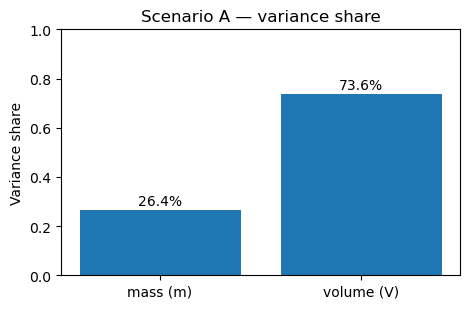


Scenario B — Kinetic Energy  K = (1/2) m v^2
Inputs (SI):
  m = 1.500 ± 0.050 kg
  v = 2.00 ± 0.10 m/s

Finite-difference propagation (independent x,y):
  K = 3.00 ± 0.32 J
  Partials (sensitivities at means):
    ∂K/∂m ≈ 2.000e+00  (units: J/kg)
    ∂K/∂v ≈ 3.000e+00  (units: J·s/m)
  Variance shares:
    from m: 10.0%
    from v: 90.0%


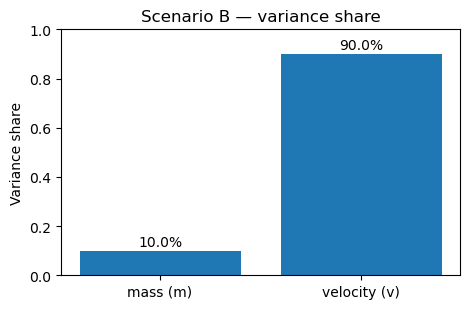

In [6]:
# Two-Variable Uncertainty Propagation

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Core helpers
# -----------------------------
def central_partial_2var(f, xbar, ybar, hx, hy, which="x"):
    """Central finite-difference partial derivative at (xbar, ybar).
       Uses hx, hy as step sizes; choose hx = σx and hy = σy for robustness.
    """
    if which == "x":
        return (f(xbar + hx, ybar) - f(xbar - hx, ybar)) / (2.0 * hx)
    else:
        return (f(xbar, ybar + hy) - f(xbar, ybar - hy)) / (2.0 * hy)

def propagate_2var(f, xbar, sx, ybar, sy):
    """First-order propagation for f(x,y) with independent uncertainties.
       Returns: f0, σ_f, ∂f/∂x, ∂f/∂y, frac_x, frac_y
    """
    # Guard against zero step: fall back to tiny relative step if needed
    hx = sx if sx > 0 else max(1e-6 * max(1.0, abs(xbar)), 1e-12)
    hy = sy if sy > 0 else max(1e-6 * max(1.0, abs(ybar)), 1e-12)

    dfdx = central_partial_2var(f, xbar, ybar, hx, hy, "x")
    dfdy = central_partial_2var(f, xbar, ybar, hx, hy, "y")
    f0   = f(xbar, ybar)

    var_x = (dfdx * sx) ** 2
    var_y = (dfdy * sy) ** 2
    var   = var_x + var_y
    sf    = np.sqrt(var)

    if var > 0:
        frac_x = var_x / var
        frac_y = var_y / var
    else:
        frac_x = np.nan
        frac_y = np.nan

    return f0, sf, dfdx, dfdy, frac_x, frac_y

def pm_str(val, sig, unit="", sigfig_unc=2):
    """Format value ± uncertainty with reasonable significant figures."""
    if not np.isfinite(sig) or sig == 0:
        return f"{val:g} {unit}".strip()
    exp = int(np.floor(np.log10(abs(sig)))) if sig != 0 else 0
    scale = 10 ** (exp - sigfig_unc + 1)
    s_r = np.round(sig / scale) * scale
    v_r = np.round(val / scale) * scale
    dec = max(0, -(exp - sigfig_unc + 1))
    fmt = f"{{:.{dec}f}}"
    return (fmt + " ± " + fmt + " {}").format(v_r, s_r, unit).strip()

def sep(title):
    print("\n" + title + "\n" + "=" * len(title))

def show_shares(title, labels, shares):
    plt.figure(figsize=(4.8, 3.2))
    plt.bar(labels, shares)
    plt.ylim(0, 1)
    plt.ylabel("Variance share")
    plt.title(title)
    for i, s in enumerate(shares):
        plt.text(i, s + 0.02, f"{100*s:.1f}%", ha="center")
    plt.tight_layout()
    plt.show()

# ----------------------------------------
# Scenario A: Density  ρ = m / V  (SI units)
# ----------------------------------------
# Given (convert V from liters to m^3 first):
m_bar, s_m = 0.250, 0.005              # kg
V_bar_L, s_V_L = 0.300, 0.010          # L
V_bar,  s_V  = V_bar_L * 1e-3, s_V_L * 1e-3   # m^3

rho = lambda m, V: m / V

sep("Scenario A — Density  ρ = m / V")
rho0, s_rho, dr_dm, dr_dV, frac_m, frac_V = propagate_2var(rho, m_bar, s_m, V_bar, s_V)

print("Inputs (SI):")
print(f"  m = {pm_str(m_bar, s_m, 'kg')}")
print(f"  V = {pm_str(V_bar, s_V, 'm^3')}  (from {V_bar_L:.3f} ± {s_V_L:.3f} L)")
print("\nFinite-difference propagation (independent x,y):")
print(f"  ρ = {pm_str(rho0, s_rho, 'kg/m^3')}")
print("  Partials (sensitivities at means):")
print(f"    ∂ρ/∂m ≈ {dr_dm:.3e}  (units: (kg/m^3)/kg)")
print(f"    ∂ρ/∂V ≈ {dr_dV:.3e}  (units: (kg/m^3)/m^3)")
print("  Variance shares:")
print(f"    from m: {100*frac_m:.1f}%")
print(f"    from V: {100*frac_V:.1f}%")

show_shares("Scenario A — variance share", ["mass (m)", "volume (V)"], [frac_m, frac_V])

# --------------------------------------------------
# Scenario B: Kinetic Energy  K = (1/2) m v^2  (SI)
# --------------------------------------------------
mK_bar, s_mK = 1.50, 0.05   # kg
v_bar,  s_v  = 2.00, 0.10   # m/s

K = lambda m, v: 0.5 * m * v**2

sep("Scenario B — Kinetic Energy  K = (1/2) m v^2")
K0, s_K, dK_dm, dK_dv, frac_mK, frac_v = propagate_2var(K, mK_bar, s_mK, v_bar, s_v)

print("Inputs (SI):")
print(f"  m = {pm_str(mK_bar, s_mK, 'kg')}")
print(f"  v = {pm_str(v_bar, s_v, 'm/s')}")
print("\nFinite-difference propagation (independent x,y):")
print(f"  K = {pm_str(K0, s_K, 'J')}")
print("  Partials (sensitivities at means):")
print(f"    ∂K/∂m ≈ {dK_dm:.3e}  (units: J/kg)")
print(f"    ∂K/∂v ≈ {dK_dv:.3e}  (units: J·s/m)")
print("  Variance shares:")
print(f"    from m: {100*frac_mK:.1f}%")
print(f"    from v: {100*frac_v:.1f}%")

show_shares("Scenario B — variance share", ["mass (m)", "velocity (v)"], [frac_mK, frac_v])

# --------------------------------------------------
# Template for your own function f(x,y)
# --------------------------------------------------
# To use:
# 1) Define your function f(x,y)
# 2) Set xbar, sx, ybar, sy
# 3) Call propagate_2var(f, xbar, sx, ybar, sy)
#
# Example (commented):
#
# f = lambda x, y: (x * y**2) / (x + y)
# xbar, sx = 2.0, 0.1
# ybar, sy = 3.0, 0.2
# f0, sf, dfdx, dfdy, fracx, fracy = propagate_2var(f, xbar, sx, ybar, sy)
# print(f"f = {pm_str(f0, sf)}")
# print(f"Partials: ∂f/∂x ≈ {dfdx:.3e}, ∂f/∂y ≈ {dfdy:.3e}")
# print(f"Variance shares: x ≈ {100*fracx:.1f}%, y ≈ {100*fracy:.1f}%")


---

## 7) Results and Discussion

For each example:
- Report $f = f(\bar x,\bar y)$ and $\sigma_f$.  
- Show both partials and the contribution percentages.  
- Comment on which uncertainty dominates and why.  
- Reflect: If $\sigma_x$ were halved, how much would $\sigma_f$ decrease?

---

## 8) Deliverables

- Completed tables for both examples (inputs, computed values, partials, $\sigma_f$).  
- Final results with correct units and reasonable significant figures.  
- Short written paragraph explaining which measurement dominates the uncertainty and why.

---

## 9) Common Pitfalls

- Mixing units (e.g., liters vs. m$^3$).  
- Using steps $h$ that are too large (nonlinear bias) or too small (round-off noise).  
- Forgetting to use **absolute** units for uncertainties.  
- Reporting $f$ with more precision than justified by $\sigma_f$.  

---

**Cool Factor:** Run the provided Python cell below to check your results numerically using both the finite-difference method and a Monte-Carlo simulation.


---

## 10) Monte Carlo Validation for the Density Example

Up to now, we used the **finite-difference method** to estimate how small independent uncertainties in $m$ and $V$ propagate into the uncertainty of the density:

$$
\rho = \frac{m}{V}.
$$

That method assumes two things:

1. The function behaves *approximately linearly* near the measured values $(\bar m,\bar V)$.
2. The uncertainties are *small enough* that higher-order terms (curvature of $f$) can be ignored.

But what if the dependence on $V$ is **strongly nonlinear** (e.g., inverse dependence),  
or what if the uncertainty in $V$ is **relatively large** compared to its mean?

To check whether the linear approximation is still reliable, we can use a **Monte Carlo simulation**.

---

### What is Monte Carlo simulation?

Instead of using derivatives, we **simulate many possible measurements** of $m$ and $V$, treating each as a random draw from their normal (Gaussian) uncertainty distributions:

$$
m \sim \mathcal N(\bar m, \sigma_m), \qquad V \sim \mathcal N(\bar V, \sigma_V).
$$

For each random pair $(m_i,V_i)$ we compute

$$
\rho_i = \frac{m_i}{V_i}.
$$

After repeating this $N$ times (for example $N=100{,}000$),  
the collection $\{\rho_i\}$ forms a *distribution* of possible densities.  
The **mean** of this distribution estimates $\bar\rho$, and its **standard deviation** gives $\sigma_\rho$ directly.

---

### Why use it here?

- $\rho = m/V$ is a **nonlinear** function (because of the division),  
  so the linear finite-difference formula might slightly underestimate or overestimate $\sigma_\rho$.
- Monte Carlo automatically includes the nonlinear curvature.
- Comparing both results lets us **validate** whether the first-order propagation is sufficient for our data.

If both agree within a few percent, the finite-difference approximation is accurate for these uncertainties.  
If not, we may need to reduce $\sigma_V$ experimentally or use MC propagation for the reported value.

---

### Expected behavior for this example

Because $\rho$ depends inversely on $V$, even small variations in $V$ produce noticeable asymmetry in $\rho_i$.  
The histogram will therefore be slightly *skewed* (longer tail to the right), even though $m$ and $V$ are normally distributed.

That skewness is precisely why it’s worth checking Monte Carlo.

---


Monte Carlo vs Finite Difference for ρ = m / V

Measured inputs:
  m = 0.250 ± 0.005 kg
  V = 0.000300 ± 0.000010 m³  (from 0.300 ± 0.010 L)

Finite-difference propagation:
  ρ = 833.333 ± 32.4207 kg/m³
Monte Carlo simulation (N=100,000):
  mean ≈ 834.424 kg/m³
  std  ≈ 32.5653 kg/m³

Relative difference in σₚ: 0.45%


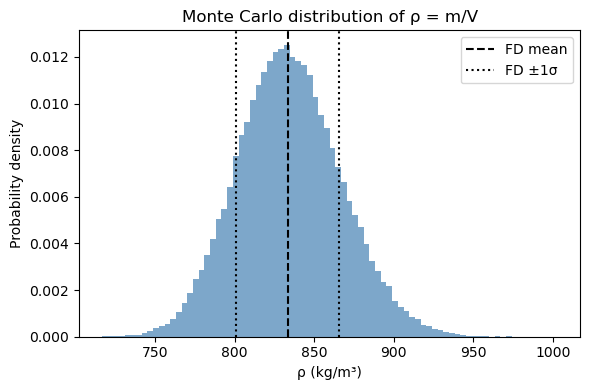


Interpretation:
• Both approaches estimate σₚ, the uncertainty in density.
• Finite-difference assumes linear behavior around the mean; Monte Carlo tests that assumption.
• A small difference (typically <5–10%) indicates the linear model is adequate.
• The slightly skewed histogram shows that the inverse relation (1/V) introduces asymmetry,
  but for these uncertainties, the difference remains small — our propagation method is valid.


In [5]:
# PHYS 2215 — Monte Carlo validation for density  ρ = m / V

import numpy as np
import matplotlib.pyplot as plt

# Given values
m_bar, s_m = 0.250, 0.005              # kg
V_bar_L, s_V_L = 0.300, 0.010          # L
V_bar,  s_V  = V_bar_L * 1e-3, s_V_L * 1e-3   # m^3
rho = lambda m, V: m / V

# ----- Finite-difference propagation (from previous lab step) -----
def central_partial_2var(f, xbar, ybar, hx, hy, which="x"):
    if which == "x":
        return (f(xbar + hx, ybar) - f(xbar - hx, ybar)) / (2.0 * hx)
    else:
        return (f(xbar, ybar + hy) - f(xbar, ybar - hy)) / (2.0 * hy)

def propagate_fd(f, xbar, sx, ybar, sy):
    dfdx = central_partial_2var(f, xbar, ybar, sx, sy, "x")
    dfdy = central_partial_2var(f, xbar, ybar, sx, sy, "y")
    f0 = f(xbar, ybar)
    var = (dfdx * sx)**2 + (dfdy * sy)**2
    return f0, np.sqrt(var)

rho_fd, s_rho_fd = propagate_fd(rho, m_bar, s_m, V_bar, s_V)

# ----- Monte Carlo sampling -----
N = 100_000
rng = np.random.default_rng(2215)
m_samples = rng.normal(m_bar, s_m, N)
V_samples = rng.normal(V_bar, s_V, N)
rho_samples = rho(m_samples, V_samples)

rho_mc_mean = float(rho_samples.mean())
rho_mc_std  = float(rho_samples.std(ddof=1))

# ----- Comparison -----
print("Monte Carlo vs Finite Difference for ρ = m / V\n")
print(f"Measured inputs:")
print(f"  m = {m_bar:.3f} ± {s_m:.3f} kg")
print(f"  V = {V_bar:.6f} ± {s_V:.6f} m³  (from {V_bar_L:.3f} ± {s_V_L:.3f} L)\n")
print(f"Finite-difference propagation:")
print(f"  ρ = {rho_fd:.6g} ± {s_rho_fd:.6g} kg/m³")
print(f"Monte Carlo simulation (N={N:,}):")
print(f"  mean ≈ {rho_mc_mean:.6g} kg/m³")
print(f"  std  ≈ {rho_mc_std:.6g} kg/m³")
print(f"\nRelative difference in σₚ: {(rho_mc_std - s_rho_fd)/s_rho_fd*100:.2f}%")

# ----- Visualization -----
plt.figure(figsize=(6,4))
plt.hist(rho_samples, bins=80, density=True, color='steelblue', alpha=0.7)
plt.axvline(rho_fd, color='k', ls='--', label='FD mean')
plt.axvline(rho_fd - s_rho_fd, color='k', ls=':', label='FD ±1σ')
plt.axvline(rho_fd + s_rho_fd, color='k', ls=':')
plt.xlabel("ρ (kg/m³)")
plt.ylabel("Probability density")
plt.title("Monte Carlo distribution of ρ = m/V")
plt.legend()
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("• Both approaches estimate σₚ, the uncertainty in density.")
print("• Finite-difference assumes linear behavior around the mean; Monte Carlo tests that assumption.")
print("• A small difference (typically <5–10%) indicates the linear model is adequate.")
print("• The slightly skewed histogram shows that the inverse relation (1/V) introduces asymmetry,")
print("  but for these uncertainties, the difference remains small — our propagation method is valid.")
